# DV-MPPCA (Deep Variational Mixture of Probabilistic Principal Component Analyzers)

**Auteur**: `Jakob De Vreese`  
**Bachelorproef**: Overdraagbare unsupervised anomaliedetectie bij hybride HVAC-systemen  
**Academiejaar**: `2025-2026`

Doel: implementatie van **DV-MPPCA** volgens *Unsupervised Fault Detection for Building Air Handling Unit Systems Using Deep Variational Mixture of Principal Component Analyzers* van Tra et al. (2024). Het model blijft zo dicht mogelijk bij de paper: een VAE-encoder/decoder, een NN-MPPCA-responsibility head en een masked loss voor ontbrekende data.

Kort: we volgen dezelfde opbouw als in de `TranAD`- en `encoder-only-transformer`-notebooks: eerst preprocessing, dan architectuur, training, tuning en ten slotte evaluatie op dezelfde synthetische dataset.

In [42]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import StandardScaler
import time
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime
from sklearn.metrics import (
confusion_matrix, classification_report, precision_recall_fscore_support,
roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
accuracy_score, balanced_accuracy_score, matthews_corrcoef,
)

In [43]:
# Herbruikbare evaluatie-toolbox voor alle architecturen (encoder-only / dv-mppca / TranAD)
def make_window_labels(y_timestep, window_size, stride=1, mode='fraction', frac_threshold=0.2):
    y_timestep = np.asarray(y_timestep).astype(int)
    labels = []
    for i in range(0, len(y_timestep) - window_size + 1, stride):
        w = y_timestep[i:i + window_size]
        if mode == 'max':
            labels.append(int(np.max(w) > 0))
        elif mode == 'center':
            labels.append(int(w[window_size // 2] > 0))
        elif mode == 'fraction':
            labels.append(int(np.mean(w) >= frac_threshold))
        else:
            raise ValueError("mode moet 'max', 'center' of 'fraction' zijn")
    return np.asarray(labels, dtype=int)


def find_event_segments(y_binary):
    y = np.asarray(y_binary).astype(int)
    segments = []
    in_seg = False
    start = 0
    for idx, v in enumerate(y):
        if v == 1 and not in_seg:
            in_seg = True
            start = idx
        elif v == 0 and in_seg:
            segments.append((start, idx - 1))
            in_seg = False
    if in_seg:
        segments.append((start, len(y) - 1))
    return segments


def event_based_metrics(y_true_binary, y_pred_binary):
    true_events = find_event_segments(y_true_binary)
    pred_events = find_event_segments(y_pred_binary)

    matched_true = 0
    for ts, te in true_events:
        overlap = any(not (pe < ts or ps > te) for ps, pe in pred_events)
        matched_true += int(overlap)

    matched_pred = 0
    for ps, pe in pred_events:
        overlap = any(not (te < ps or ts > pe) for ts, te in true_events)
        matched_pred += int(overlap)

    event_recall = matched_true / len(true_events) if len(true_events) else 0.0
    event_precision = matched_pred / len(pred_events) if len(pred_events) else 0.0
    if event_precision + event_recall == 0:
        event_f1 = 0.0
    else:
        event_f1 = 2.0 * event_precision * event_recall / (event_precision + event_recall)

    return {
        'event_precision': event_precision,
        'event_recall': event_recall,
        'event_f1': event_f1,
        'n_true_events': len(true_events),
        'n_pred_events': len(pred_events),
        'matched_true_events': matched_true,
        'matched_pred_events': matched_pred,
    }


def build_reusable_scorecard(y_true_window, scores_window, threshold, model_name='model'):
    from sklearn.metrics import (
        confusion_matrix,
        precision_recall_fscore_support,
        roc_auc_score,
        average_precision_score,
        accuracy_score,
        balanced_accuracy_score,
        matthews_corrcoef,
    )

    y_true_window = np.asarray(y_true_window).astype(int)
    scores_window = np.asarray(scores_window).astype(float)
    y_pred_window = (scores_window > threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_window, y_pred_window, average='binary', zero_division=0
    )
    cm = confusion_matrix(y_true_window, y_pred_window)
    accuracy = accuracy_score(y_true_window, y_pred_window)
    balanced_acc = balanced_accuracy_score(y_true_window, y_pred_window)
    mcc = matthews_corrcoef(y_true_window, y_pred_window)
    roc_auc = roc_auc_score(y_true_window, scores_window) if len(np.unique(y_true_window)) > 1 else np.nan
    pr_auc = average_precision_score(y_true_window, scores_window) if len(np.unique(y_true_window)) > 1 else np.nan

    evt = event_based_metrics(y_true_window, y_pred_window)

    metrics_df = pd.DataFrame({
        'Model': [model_name] * 11,
        'Metric': [
            'Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1',
            'MCC', 'ROC-AUC', 'PR-AUC', 'Event Precision', 'Event Recall', 'Event F1'
        ],
        'Value': [
            accuracy, balanced_acc, precision, recall, f1,
            mcc, roc_auc, pr_auc, evt['event_precision'], evt['event_recall'], evt['event_f1']
        ]
    })

    return {
        'threshold': float(threshold),
        'metrics_df': metrics_df,
        'confusion_matrix': cm,
        'y_pred_window': y_pred_window,
        'event_details': evt,
    }


def tune_threshold_by_f1(scores, y_true, q_low=0.90, q_high=0.999, n=250):
    from sklearn.metrics import precision_recall_fscore_support

    scores = np.asarray(scores).astype(float)
    y_true = np.asarray(y_true).astype(int)
    candidates = np.unique(np.quantile(scores, np.linspace(q_low, q_high, n)))

    best_t = float(candidates[0])
    best_f1 = -1.0
    for t in candidates:
        y_hat = (scores > t).astype(int)
        _, _, f1, _ = precision_recall_fscore_support(y_true, y_hat, average='binary', zero_division=0)
        if f1 > best_f1:
            best_f1 = float(f1)
            best_t = float(t)
    return best_t, best_f1

## STAP 1 - Data Preprocessing

DV-MPPCA werkt op individuele meetpunten in plaats van op sliding windows. We houden daarom de preprocessing compact: chronologische splitsing, standaardisatie op de trainset en een aparte validatiesplit voor calibratie.

1. Data inladen en chronologisch splitsen
2. Train/val/test scheiden zonder shuffle
3. Standaardiseren met `StandardScaler` en converteren naar `float32`

### 1.1 Dataset inlezen

In [44]:
# Dataset inlezen
GEBOUW = 'dunant1'

url = f'../02_eda_en_ground_truth/processed/{GEBOUW}_train.csv'
data = pd.read_csv(url)
data.head()

,timestamp,f_1,f_2,f_3,f_4,f_6,f_7,f_8,f_9,f_10,...,f_50,f_51,f_52,f_53,f_54,f_55,is_weekdag,is_weekend,is_werkuur,uur
0,2026-03-09 00:10:00+00:00,7.0,0.77,1.0,39.877285,31.832268,1.0,23.594538,44.640636,1.0,...,0.0,3.851797,99.589400,0.749325,86.946641,0.0,1,0,0,0
1,2026-03-09 00:20:00+00:00,9.0,0.78,1.0,41.921010,34.104786,1.0,46.930084,44.640636,1.0,...,0.0,3.903977,100.000000,0.559565,45.771835,0.0,1,0,0,0
2,2026-03-09 00:30:00+00:00,8.0,0.86,1.0,43.412975,35.585346,1.0,43.235270,44.640636,0.0,...,0.0,4.244891,99.196013,0.322963,91.228401,0.0,1,0,0,0
3,2026-03-09 00:40:00+00:00,7.0,0.78,1.0,43.734930,35.924030,1.0,48.845810,44.640636,0.0,...,0.0,4.448537,98.800579,0.300000,323.796930,0.0,1,0,0,0
4,2026-03-09 00:50:00+00:00,9.0,0.78,1.0,44.037724,36.229050,1.0,44.068630,44.640636,0.0,...,0.0,4.748848,99.259927,0.345344,204.933704,0.0,1,0,0,0


In [45]:
print(data.shape)

(6997, 59)


### 1.2 Chronologische Train/Val/Test split

In [46]:
# Drop timestamp
if 'timestamp' in data.columns:
    data = data.drop(columns='timestamp')

# Chronologische splitsing: train (80%) en test (20%)
split_index = int(len(data) * 0.8)
train_data_full = data.iloc[:split_index]
test_data = data.iloc[split_index:]

# Extra validatiesplit uit het einde van de trainset voor calibratie
val_ratio = 0.15
val_start = int(len(train_data_full) * (1 - val_ratio))
train_data = train_data_full.iloc[:val_start]
val_data = train_data_full.iloc[val_start:]

print(f"Train data shape: {train_data.shape}")
print(f"Val data shape: {val_data.shape}")
print(f"Test data shape: {test_data.shape}")

Train data shape: (4757, 58)
Val data shape: (840, 58)
Test data shape: (1400, 58)


In [47]:
print(f"Train/Val/Test: {train_data.shape} | {val_data.shape} | {test_data.shape}")

Train/Val/Test: (4757, 58) | (840, 58) | (1400, 58)


### 1.3 Normalisatie van de data

In [48]:
scaler = StandardScaler()
X_train = scaler.fit_transform(train_data).astype(np.float32)
X_val = scaler.transform(val_data).astype(np.float32)
X_test = scaler.transform(test_data).astype(np.float32)

print(f"Vorm van de training data (X_train): {X_train.shape}")
print(f"Vorm van de validatie data (X_val): {X_val.shape}")
print(f"Vorm van de test data (X_test): {X_test.shape}")

Vorm van de training data (X_train): (4757, 58)
Vorm van de validatie data (X_val): (840, 58)
Vorm van de test data (X_test): (1400, 58)


## STAP 2 - De DV-MPPCA Architectuur (Keras)

We houden de architectuur compact en paper-gericht: een encoder die $\mu$ en $\log(\sigma^2)$ leert, een sampling-layer, een decoder voor reconstructie en een NN-MPPCA-head voor responsibilities.

De componenten staan hieronder als losse Keras-lagen zodat de opbouw goed leesbaar en herstartbaar blijft.

### 2.1 De VAE Encoder (Compressie)

Het eerste deel van de architectuur is de encoder van de Variational Autoencoder (VAE). Het doel van dit netwerk is om de hoog-dimensionale, ruwe sensordata ($x$) samen te persen naar een veel kleinere, abstracte 'latente ruimte'. 

In plaats van één vaste waarde per dimensie te voorspellen, voorspelt een VAE een **kansverdeling**. De encoder geeft voor elke latente dimensie twee parameters terug:
* **$\mu$ (mu)**: Het gemiddelde van de verdeling.
* **$\log(\sigma^2)$ (logvar)**: De logaritme van de variantie. We gebruiken de logaritme omdat de output van een neuraal netwerk negatief kan zijn, terwijl een variantie altijd positief moet zijn.

In [49]:
class VAE_Encoder(layers.Layer):
    def __init__(self, latent_dim, **kwargs):
        super(VAE_Encoder, self).__init__(**kwargs)
        # Twee verborgen lagen voor extractie van kenmerken
        self.fc1 = layers.Dense(64, activation='relu')
        self.fc2 = layers.Dense(32, activation='relu')
        
        # Output lagen voor de parameters van de kansverdeling
        self.fc_mu = layers.Dense(latent_dim, name='encoder_mu')
        self.fc_logvar = layers.Dense(latent_dim, name='encoder_logvar')

    def call(self, x):
        h = self.fc1(x)
        h = self.fc2(h)
        
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

### 2.2 De Reparameterization Trick & Latente Kenmerken ($z_c$)

Om verder te kunnen rekenen, moeten we een concrete waarde (een sample) trekken uit de kansverdeling die de encoder heeft gedefinieerd. Dit vormt onze latente vector **$z_c$**.

We kunnen echter niet zomaar willekeurig samplen met een standaard random-functie, want dan wordt de wiskundige ketting gebroken en kan de *backpropagation* (het trainen van het netwerk) de encoder niet bereiken. De oplossing hiervoor is de **Reparameterization Trick**:
We samplen een willekeurige ruis $\epsilon$ uit een standaard normale verdeling (gemiddelde 0, variantie 1) en transformeren deze met onze geleerde $\mu$ en $\sigma$:
$$z_c = \mu + \epsilon \cdot \sigma$$
Hierdoor kan het model leren, terwijl het toch willekeurigheid bevat.

In [50]:
class Sampling(layers.Layer):
    """Gebruikt (mu, logvar) om een latente vector z_c te samplen."""
    def call(self, inputs):
        mu, logvar = inputs
        # Dimensies ophalen voor de ruis matrix
        batch_size = tf.shape(mu)[0]
        dim = tf.shape(mu)[1]
        
        # Sample epsilon (ruis) uit een standaard normale verdeling (N(0, 1))
        epsilon = tf.random.normal(shape=(batch_size, dim))
        
        # Converteer logvar naar standaardafwijking (sigma)
        # exp(0.5 * logvar) is wiskundig gelijk aan de vierkantswortel van de variantie
        sigma = tf.exp(0.5 * logvar)
        
        # Reparameterization formule: z_c = mu + epsilon * sigma
        return mu + epsilon * sigma

### 2.3 De VAE Decoder & Reconstructiefout ($z_r$)

De decoder neemt de gecomprimeerde latente vector $z_c$ en probeert hieruit de originele sensordata perfect na te bouwen ($x_{recon}$). 

De paper stelt dat we niet alleen geïnteresseerd zijn in $z_c$, maar ook in de **reconstructiefout**. Als een sensor kapot is, zal de VAE deze afwijking niet goed kunnen reconstrueren. Het verschil tussen de echte input en de reconstructie vormt de foutvector **$z_r$**:
$$z_r = x - x_{recon}$$
Beide vectoren ($z_c$ en $z_r$) bevatten cruciale informatie voor de anomaliedetectie.

In [51]:
class VAE_Decoder(layers.Layer):
    def __init__(self, input_dim, **kwargs):
        super(VAE_Decoder, self).__init__(**kwargs)
        # Vertaal de latente vector terug naar de originele dimensies
        self.fc1 = layers.Dense(32, activation='relu')
        self.fc2 = layers.Dense(64, activation='relu')
        self.fc_out = layers.Dense(input_dim, name='reconstruction_output')

    def call(self, z_c):
        h = self.fc1(z_c)
        h = self.fc2(h)
        x_recon = self.fc_out(h)
        return x_recon

### 2.4 Het NN-MPPCA Netwerk (Dichtheidsschatting)

De traditionele MPPCA (Mixture of Probabilistic Principal Component Analyzers) is een wiskundig clustermodel dat getraind wordt via het Expectation-Maximization (EM) algoritme. De grote innovatie van Tra et al. (2024) is dat zij dit model hebben omgeschreven naar een neuraal netwerk, zodat het gelijktijdig met de VAE getraind kan worden via backpropagation.

Dit netwerk krijgt een **derivative vector ($v_n$)** als input. Dit is simpelweg het aan elkaar plakken (concatenation) van de latente vector $z_c$ en de foutvector $z_r$. 
Op basis van $v_n$ berekent een Softmax-laag de waarschijnlijkheid dat deze specifieke meting tot een van de gedefinieerde clusters behoort (de *responsibility matrix* $r_n$).

In [52]:
class NN_MPPCA(layers.Layer):
    def __init__(self, num_components, **kwargs):
        super(NN_MPPCA, self).__init__(**kwargs)
        # Een kleine hidden layer om de samengevoegde vector te verwerken
        self.fc1 = layers.Dense(32, activation='relu')
        
        # De Softmax output wijst een waarschijnlijkheid toe aan elk van de 'num_components' clusters
        self.fc_out = layers.Dense(num_components, activation='softmax', name='responsibility_matrix')

    def call(self, v_n):
        h = self.fc1(v_n)
        r_n = self.fc_out(h)
        return r_n

### 2.5 Het Volledige DV-MPPCA Model Samenstellen

Nu alle bouwblokken gedefinieerd zijn, brengen we ze samen in één overkoepelende `tf.keras.Model` klasse. Dit beheert de datastroom van de ruwe input $x$ tot aan de uiteindelijke MPPCA-clustering $r_n$.

In [53]:
class DV_MPPCA_Model(Model):
    def __init__(self, input_dim, latent_dim, num_components, **kwargs):
        super(DV_MPPCA_Model, self).__init__(**kwargs)
        
        # Initialiseer de custom componenten
        self.encoder = VAE_Encoder(latent_dim)
        self.sampling = Sampling()
        self.decoder = VAE_Decoder(input_dim)
        self.mppca_estimator = NN_MPPCA(num_components)

    def call(self, x):
        # 1. Compressie: Verkrijg de distributie parameters
        mu, logvar = self.encoder(x)
        
        # 2. Samplen: Creëer de latente vector z_c
        z_c = self.sampling([mu, logvar])
        
        # 3. Reconstructie: Bouw x terug op
        x_recon = self.decoder(z_c)
        
        # 4. Foutbepaling: Bereken de residual features z_r
        z_r = x - x_recon
        
        # 5. Samenvoegen: Creëer de derivative vector v_n door z_c en z_r te combineren
        v_n = tf.concat([z_c, z_r], axis=1)
        
        # 6. Dichtheidsschatting: Bepaal de clusterwaarschijnlijkheden r_n
        r_n = self.mppca_estimator(v_n)
        
        # We retourneren alle interne staten die nodig zijn voor de M-ELBO verliesfunctie
        return x_recon, mu, logvar, z_c, v_n, r_n

In [54]:
# Parameters en initialisatie controleren
INPUT_DIM = X_train.shape[1]
LATENT_DIM = 10
NUM_COMPONENTS = 5

dv_mppca = DV_MPPCA_Model(input_dim=INPUT_DIM, latent_dim=LATENT_DIM, num_components=NUM_COMPONENTS)

# Forceer het bouwen van de variabelen door dummy data door het netwerk te sturen
dv_mppca.build(input_shape=(None, INPUT_DIM))

# Print een overzicht van de architectuur en het aantal gewichten
dv_mppca.summary()

/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'dv_mppca__model_8', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "dv_mppca__model_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vae__encoder_8 (VAE_Encoder)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sampling_8 (Sampling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae__decoder_8 (VAE_Decoder)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ nn_mppca_8 (NN_MPPCA)           │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## STAP 3 - Verliesfuncties (M-ELBO & MPPCA Entropy)

De verliesfunctie combineert drie delen: gemaskeerde reconstructiefout, KL-regularisatie en een entropieterm voor de MPPCA-responsibilities. Zo blijft ontbrekende data buiten de loss, maar blijft de latente ruimte wel gestructureerd.

### 3.1 Reconstructiefout met Maskering

Bij een standaard autoencoder wordt de *Mean Squared Error* (MSE) berekend over de volledige inputvector. Als een fysieke sensor in het HVAC-systeem echter uitvalt of `NaN`-waarden doorstuurt, zou het model ten onrechte proberen deze foutieve signalen te leren.

De M-ELBO lost dit op via een binaire indicatormatrix (het `mask`). Als een sensorwaarde geldig is, is de maskwaarde `1`. Is de data vermist of corrupt, dan is de maskwaarde `0`. Door de kwadratische fout te vermenigvuldigen met deze maskermatrix, wordt de foutmarge voor kapotte sensoren direct naar nul geforceerd. Het model optimaliseert zijn gewichten hierdoor uitsluitend op basis van de op dat moment *werkende* sensoren.

### 3.2 Kullback-Leibler (KL) Divergentie

De tweede component van de M-ELBO is de KL-divergentie, een typische regularisatieterm voor Variational Autoencoders. 

Deze term dwingt de kansverdeling die door de encoder is geleerd (met parameters $\mu$ en $\log(\sigma^2)$) om zo dicht mogelijk bij een standaard normale verdeling ($\mathcal{N}(0,1)$) te blijven. Zonder de KL-divergentie zou het model specifieke datapunten exact in de latente ruimte opslaan (overfitting), in plaats van een soepele, generaliseerbare kansverdeling te vormen waaruit robuuste datapunten gesampled kunnen worden.

### 3.3 NN-MPPCA Entropy Loss

Het NN-MPPCA deel van het model geeft een waarschijnlijkheidsmatrix ($r_n$) terug, waarbij elke rij aangeeft in welke mate een meting tot een specifieke cluster behoort. 

In de oorspronkelijke MPPCA gebeurt dit via een iteratief *Expectation-Maximization* (EM) algoritme. Om dit te emuleren in een neuraal netwerk met backpropagation, moeten we voorkomen dat de outputlaag 'lui' wordt en simpelweg alle datapunten aan één grote cluster toewijst. Door de **Entropie** (de wiskundige onzekerheid) van de clusterverdeling als penalty (loss) toe te voegen, dwingen we het netwerk om scherpe onderscheidingen te maken en de data logisch te verdelen over het vooraf ingestelde aantal componenten.

In [55]:
@tf.function
def combined_loss_tf(x, x_recon, mu, logvar, r_n, mask):
    """
    Berekent de totale verliesfunctie voor het DV-MPPCA framework.
    
    Parameters:
    - x: Originele input (batch_size, input_dim)
    - x_recon: Door de VAE gereconstrueerde input
    - mu, logvar: Latente parameters uit de encoder
    - r_n: Cluster waarschijnlijkheden van de NN-MPPCA (responsibility matrix)
    - mask: Matrix met 1 voor geldige data, 0 voor missing data
    """
    # 1. Reconstructiefout (M-ELBO: Uitsluitend berekend op mask == 1)
    # tf.square(x - x_recon) berekent de kwadratische fout per individuele sensor
    recon_loss_per_feature = tf.square(x - x_recon) * mask
    recon_loss = tf.reduce_sum(recon_loss_per_feature, axis=1)
    
    # 2. Kullback-Leibler (KL) Divergentie
    # Standaard formule voor de afstand tussen de geleerde verdeling en N(0,1)
    kl_loss = -0.5 * tf.reduce_sum(1.0 + logvar - tf.square(mu) - tf.exp(logvar), axis=1)
    
    # Het gemiddelde M-ELBO verlies over de volledige batch
    vae_loss = tf.reduce_mean(recon_loss + kl_loss)
    
    # 3. NN-MPPCA Entropy Loss 
    # Minimaliseer entropie om cluster-absorptie te voorkomen.
    # De 1e-8 term is numerieke stabiliteit om tf.math.log(0) crashes te vermijden.
    entropy = -tf.reduce_sum(r_n * tf.math.log(r_n + 1e-8), axis=1)
    mppca_loss = tf.reduce_mean(entropy)
    
    # De uiteindelijke loss is de som van het compressienetwerk en de dichtheidsschatting
    return vae_loss + mppca_loss

## STAP 4 - De Trainingsloop (met Missing Data Simulatie)

De trainingslus blijft custom, maar klein: per batch maskeren we willekeurig waarden, voeren we een forward pass uit en optimaliseren we de gecombineerde loss. Dat maakt de code vergelijkbaar met de andere notebooks en tegelijk trouw aan de paper.

### 4.1 Hyperparameters & Datavoorbereiding

We definiëren de standaardvariabelen en verpakken onze genormaliseerde `numpy` arrays in een efficiënte `tf.data.Dataset`. Omdat we werken met onafhankelijke tijdstappen (en niet met sliding windows zoals bij de Transformer), is het willekeurig schudden (`shuffle`) van de rijen toegestaan en zelfs aanbevolen om het model stabieler te laten leren.

In [56]:
# Hyperparameters
NUM_EPOCHS = 10
BATCH_SIZE = 64
LEARNING_RATE = 1e-3

In [57]:
# We gebruiken de eerder gedefinieerde X_train (reeds float32)
# TensorFlow Dataset aanmaken voor efficiënte batching en shuffling
train_dataset = tf.data.Dataset.from_tensor_slices(X_train)
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE)

# Optimizer initialiseren
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

### 4.2 De Custom Training Step

Hier definiëren we de logica die per batch wordt uitgevoerd. Het cruciale onderdeel hier is de **maskering**. 

In tegenstelling tot de Transformer (die aaneengesloten blokken maskeerde), passen we hier een simpelere waarschijnlijkheidsmaskering toe. Voor elk individueel datapunt in de batch genereren we een willekeurig getal. Is dat getal lager dan 0.10, dan zetten we de maskwaarde op `0` (we simuleren dat de sensor stuk is). De ingangswaarde wordt dan ook overschreven met een `0` (wat overeenkomt met het gemiddelde, aangezien onze data gestandaardiseerd is).

Vervolgens berekent de `GradientTape` de verliesfunctie, waarbij de `combined_loss_tf` uit Stap 3 de kapotte sensoren netjes negeert.

In [58]:
@tf.function
def train_step(batch_x, model, optimizer):
    # 1. Dynamisch masker genereren (Simuleer 10% missing data)
    # tf.random.uniform geeft getallen tussen 0 en 1
    rand_tensor = tf.random.uniform(shape=tf.shape(batch_x))
    
    # Als het getal groter is dan 0.10, behouden we de data (masker = 1.0)
    # Anders beschouwen we het als missend (masker = 0.0)
    mask = tf.cast(rand_tensor > 0.10, tf.float32)
    
    # 2. Corrumpeer de inputdata: vermenigvuldig met het masker
    # Waarden waar mask=0 is, worden 0.0. 
    masked_x = batch_x * mask
    
    # 3. Forward pass en gradiëntberekening
    with tf.GradientTape() as tape:
        # We geven de GEMASKEERDE data aan het model
        x_recon, mu, logvar, z_c, v_n, r_n = model(masked_x, training=True)
        
        # We berekenen de loss door de reconstructie te vergelijken met de ORIGINELE (batch_x) data,
        # gebruikmakend van het masker om de met opzet verwijderde data te negeren in de loss.
        loss = combined_loss_tf(batch_x, x_recon, mu, logvar, r_n, mask)
        
    # 4. Backpropagation
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    
    return loss

### 4.3 De Iteratieve Epoch Loop

Ten slotte zetten we de loop op die de dataset meerdere keren doorloopt. We houden per epoch de gemiddelde M-ELBO + MPPCA loss bij om de convergentie van het DV-MPPCA model in de gaten te houden.

*(Let op: Als we later in Stap 5 hyperparameter tuning doen, zullen we deze `train_step` en loop lokaal binnen de tuning-for-loop moeten definiëren om TensorFlow graph-errors te voorkomen, exact zoals we bij de Transformer hebben gedaan. Voor een enkele run werkt onderstaande code perfect).*

In [59]:
print("Start van de DV-MPPCA training...")

# Om de loop te testen, maken we een enkel testmodel aan
test_model = DV_MPPCA_Model(input_dim=INPUT_DIM, latent_dim=10, num_components=5)
test_model.build(input_shape=(None, INPUT_DIM))

for epoch in range(NUM_EPOCHS):
    start_time = time.time()
    
    # Keras variabele om het gemiddelde verlies bij te houden
    epoch_loss_avg = tf.keras.metrics.Mean()
    
    # Loop over alle batches in de trainingsset
    for batch_x in train_dataset:
        loss_value = train_step(batch_x, test_model, optimizer)
        epoch_loss_avg.update_state(loss_value)
        
    end_time = time.time()
    epoch_duration = end_time - start_time
    
    print(f"Epoch {epoch + 1:02d}/{NUM_EPOCHS:02d} | "
          f"Gemiddelde Loss: {epoch_loss_avg.result().numpy():.4f} | "
          f"Tijd: {epoch_duration:.1f}s")

print("Training voltooid.")

Start van de DV-MPPCA training...


/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'dv_mppca__model_9', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Epoch 01/10 | Gemiddelde Loss: 47.1910 | Tijd: 2.3s
Epoch 02/10 | Gemiddelde Loss: 34.1785 | Tijd: 0.2s
Epoch 03/10 | Gemiddelde Loss: 29.1355 | Tijd: 0.2s
Epoch 04/10 | Gemiddelde Loss: 27.1524 | Tijd: 0.2s
Epoch 05/10 | Gemiddelde Loss: 25.2945 | Tijd: 0.2s
Epoch 06/10 | Gemiddelde Loss: 24.2646 | Tijd: 0.2s
Epoch 07/10 | Gemiddelde Loss: 23.2832 | Tijd: 0.2s
Epoch 08/10 | Gemiddelde Loss: 22.1221 | Tijd: 0.2s
Epoch 09/10 | Gemiddelde Loss: 21.4002 | Tijd: 0.2s
Epoch 10/10 | Gemiddelde Loss: 20.5716 | Tijd: 0.2s
Training voltooid.


## STAP 5 - Hyperparameter Tuning & Model Opslaan

We tunen hier vooral `latent_dim`, `num_components` en de learning rate. De zoeklus blijft bewust compact, met dezelfde stijl als in de andere notebooks: proefmodel, validatieverlies, beste configuratie opslaan.

### 5.1 Grid samenstellen

In [60]:
from itertools import product

latent_dims = [4, 8, 12, 16]
num_components_options = [2, 3, 5]
learning_rates = [1e-3, 5e-4]
mask_ratios = [0.05, 0.10]

tuning_epochs = 8

hyperparameter_grid = [
    {
        'latent_dim': latent_dim,
        'num_components': num_components,
        'learning_rate': learning_rate,
        'mask_ratio': mask_ratio,
    }
    for latent_dim, num_components, learning_rate, mask_ratio in product(
        latent_dims,
        num_components_options,
        learning_rates,
        mask_ratios,
    )
]

print(f'Hyperparameter grid size: {len(hyperparameter_grid)}')
print(f'Tuning epochs per trial: {tuning_epochs}')

Hyperparameter grid size: 48
Tuning epochs per trial: 8


### 5.2 Loop over de grid

In [61]:
best_loss = float('inf')
best_model = None
best_params = None
tuning_records = []

print('Start DV-MPPCA Hyperparameter Tuning...')

# 2. Maak een clean validatie dataset op basis van de niet-gecorrumpeerde validatiesplit
validation_dataset = tf.data.Dataset.from_tensor_slices(X_val).batch(BATCH_SIZE)

# 3. Loop over de configuraties
for trial_idx, params in enumerate(hyperparameter_grid, start=1):
    print(f"\n--- Trial {trial_idx}/{len(hyperparameter_grid)}: {params} ---")

    mask_ratio = float(params.get('mask_ratio', 0.10))
    trial_epochs = int(params.get('epochs', tuning_epochs))

    # Initialiseer een vers model en bouw de lagen
    temp_model = DV_MPPCA_Model(
        input_dim=INPUT_DIM,
        latent_dim=params['latent_dim'],
        num_components=params['num_components']
    )
    temp_model.build(input_shape=(None, INPUT_DIM))
    temp_optimizer = tf.keras.optimizers.Adam(learning_rate=params['learning_rate'])

    # 4. Lokale Train Step met dynamische M-ELBO maskering
    @tf.function
    def current_train_step(batch_x):
        rand_tensor = tf.random.uniform(shape=tf.shape(batch_x))
        mask = tf.cast(rand_tensor > mask_ratio, tf.float32)
        masked_x = batch_x * mask

        with tf.GradientTape() as tape:
            x_recon, mu, logvar, z_c, v_n, r_n = temp_model(masked_x, training=True)
            loss = combined_loss_tf(batch_x, x_recon, mu, logvar, r_n, mask)

        gradients = tape.gradient(loss, temp_model.trainable_variables)
        temp_optimizer.apply_gradients(zip(gradients, temp_model.trainable_variables))
        return loss

    # 5. Lokale validatiestap zonder kunstmatige maskering
    @tf.function
    def current_validation_step(batch_x):
        x_recon, mu, logvar, z_c, v_n, r_n = temp_model(batch_x, training=False)
        mask = tf.ones_like(batch_x)
        return combined_loss_tf(batch_x, x_recon, mu, logvar, r_n, mask)

    # 6. Korte trainingsloop voor deze specifieke configuratie
    for epoch in range(trial_epochs):
        epoch_loss_avg = tf.keras.metrics.Mean()
        for batch_x in train_dataset:
            loss_value = current_train_step(batch_x)
            epoch_loss_avg.update_state(loss_value)

    # 7. Evalueer op de clean validatieset
    validation_loss_avg = tf.keras.metrics.Mean()
    for batch_x in validation_dataset:
        validation_loss_avg.update_state(current_validation_step(batch_x))

    train_loss_value = float(epoch_loss_avg.result().numpy())
    validation_loss_value = float(validation_loss_avg.result().numpy())

    tuning_records.append({
        'trial': trial_idx,
        'latent_dim': params['latent_dim'],
        'num_components': params['num_components'],
        'learning_rate': params['learning_rate'],
        'mask_ratio': mask_ratio,
        'epochs': trial_epochs,
        'train_loss': train_loss_value,
        'validation_loss': validation_loss_value,
    })

    print(f"Train Loss: {train_loss_value:.4f} | Validation Loss: {validation_loss_value:.4f}")

    # 8. Selecteer het beste model op basis van validatieverlies
    if validation_loss_value < best_loss:
        best_loss = validation_loss_value
        best_model = temp_model
        best_params = dict(params)
        best_params['mask_ratio'] = mask_ratio
        best_params['epochs'] = trial_epochs


tuning_summary_df = pd.DataFrame(tuning_records).sort_values(
    ['validation_loss', 'train_loss', 'latent_dim', 'num_components'],
    ascending=[True, True, True, True],
).reset_index(drop=True)

print('\nTop 10 tuningresultaten:')
print(tuning_summary_df.head(10).to_string(index=False))
print(f"\nBeste configuratie gevonden: {best_params} met validation loss: {best_loss:.4f}")

Start DV-MPPCA Hyperparameter Tuning...

--- Trial 1/48: {'latent_dim': 4, 'num_components': 2, 'learning_rate': 0.001, 'mask_ratio': 0.05} ---


/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'dv_mppca__model_10', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Train Loss: 21.0572 | Validation Loss: 21.4609

--- Trial 2/48: {'latent_dim': 4, 'num_components': 2, 'learning_rate': 0.001, 'mask_ratio': 0.1} ---


/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'dv_mppca__model_11', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Train Loss: 20.6758 | Validation Loss: 22.0395

--- Trial 3/48: {'latent_dim': 4, 'num_components': 2, 'learning_rate': 0.0005, 'mask_ratio': 0.05} ---


...

Train Loss: 23.8633 | Validation Loss: 24.8694

--- Trial 47/48: {'latent_dim': 16, 'num_components': 5, 'learning_rate': 0.0005, 'mask_ratio': 0.05} ---


/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'dv_mppca__model_56', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Train Loss: 27.8342 | Validation Loss: 26.9658

--- Trial 48/48: {'latent_dim': 16, 'num_components': 5, 'learning_rate': 0.0005, 'mask_ratio': 0.1} ---


/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'dv_mppca__model_57', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
2026-05-03 14:02:00.223857: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Train Loss: 29.1656 | Validation Loss: 28.8673

Top 10 tuningresultaten:
 trial  latent_dim  num_components  learning_rate  mask_ratio  epochs  train_loss  validation_loss
     9           4               5          0.001        0.05       8   20.160463        20.949818
    10           4               5          0.001        0.10       8   20.602144        21.459322
     1           4               2          0.001        0.05       8   21.057196        21.460896
    17           8               3          0.001        0.05       8   21.345215        21.749523
     5           4               3          0.001        0.05       8   21.421656        21.802982
    18           8               3          0.001        0.10       8   22.245045        22.002188
     2           4               2          0.001        0.10       8   20.675755        22.039494
    14           8               2          0.001        0.10       8   21.349171        22.227690
    21           8               5  

### 5.3 Beste model opslaan

In [62]:
# 6. Het beste model opslaan op de schijf
gebouw_naam = "dunant1"
huidige_datum = datetime.now().strftime("%Y-%m-%d")
model_dir = "models"
os.makedirs(model_dir, exist_ok=True) 

# Keras .weights.h5 extensie gebruiken
save_path = f"{model_dir}/dv-mppca-{gebouw_naam}-{huidige_datum}.weights.h5"
best_model.save_weights(save_path)

print(f"Beste model succesvol opgeslagen in: {save_path}")

Beste model succesvol opgeslagen in: models/dv-mppca-dunant1-2026-05-03.weights.h5


## STAP 6 - Inferentie: Dichtheidsschatting en Baseline Drempel

De inferentie volgt dezelfde logica als in de andere notebooks: eerst een clean calibratieset gebruiken om een threshold te bepalen, daarna die threshold toepassen op de gelabelde synthetische dataset.

### 6.1 Model Herladen (Praktijksimulatie)

We initialiseren een nieuw modelobject met de optimale hyperparameters die we in Stap 5 hebben gevonden (`best_params`). Vervolgens laden we de getrainde gewichten (`.weights.h5`) in. Dit nabootst hoe het systeem in een live gebouwbeheersysteem zou worden geïmplementeerd.

In [63]:
# 1. Model opnieuw initialiseren met de beste gevonden parameters
loaded_model = DV_MPPCA_Model(
    input_dim=INPUT_DIM,
    latent_dim=best_params['latent_dim'],
    num_components=best_params['num_components']
)

# 2. Forceer de TensorFlow graaf om op te bouwen door er dummy data doorheen te sturen
loaded_model.build(input_shape=(None, INPUT_DIM))
loaded_model(tf.zeros((1, INPUT_DIM)))

# 3. Laad de getrainde gewichten in
loaded_model.load_weights(save_path)
print("DV-MPPCA modelgewichten succesvol ingeladen!")

DV-MPPCA modelgewichten succesvol ingeladen!


/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'dv_mppca__model_58', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


### 6.2 De Anomaly Score Berekenen (Proxy-methode)

In de pure wiskundige vorm berekent het MPPCA-model de Negative Log-Likelihood ($- \log(p(v_n))$) over alle clusters als anomaliescore. 

In onze Keras-architectuur gebruiken we een directe proxy die nauw verbonden is met de theorie: de **reconstructiefout van de VAE-component ($z_r$)**. Als een sensor kapot is, zal de gecomprimeerde latente vector ($z_c$) de fout niet bevatten, waardoor de decoder de originele kapotte waarde niet kan reproduceren. De resulterende grote Mean Squared Error (MSE) fungeert als een betrouwbare indicator voor een anomalie.

Omdat DV-MPPCA werkt op individuele tijdstappen (geen *sliding windows*), berekenen we de fout simpelweg per rij.

In [64]:
# 1. Converteer de validatiedata naar een TensorFlow tensor
X_val_tf = tf.cast(X_val, tf.float32)

# 2. Voer inferentie uit op de volledige validatieset
# We halen alle outputs op, maar zijn voor de score vooral geïnteresseerd in x_recon
x_recon, mu, logvar, z_c, v_n, r_n = loaded_model.predict(X_val_tf, batch_size=BATCH_SIZE)

# 3. Bereken de anomaly score (Mean Squared Error per individuele tijdstap)
# axis=-1 zorgt ervoor dat we het gemiddelde nemen over alle 54 sensoren per specifiek meetmoment
scores_val = np.mean(np.square(X_val - x_recon), axis=-1)

print(f"Vorm van de berekende anomaliescores: {scores_val.shape}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Vorm van de berekende anomaliescores: (840,)


### 6.3 Statistische Baseline Drempel (Threshold) instellen

Om te bepalen wanneer een score hoog genoeg is om een alarm te genereren in het FDD-systeem (Fault Detection and Diagnostics), hebben we een vaste grens nodig. 

We gebruiken eerst de clean validatieset uit Stap 6 om een deployment-threshold te kalibreren via een percentile-regel. Daarna gebruiken we de gelabelde synthetische subset enkel om het operationele punt te benchmarken en te verfijnen, zodat de eindscore op de ground-truth testset niet wordt gebruikt voor calibratie zelf.

In [65]:
# Bereken het 99e percentiel van de scores uit de foutvrije validatieset
baseline_threshold = np.percentile(scores_val, 99)

print(f"Berekende Baseline Alarmgrens (99e percentiel): {baseline_threshold:.4f}")

# Ter illustratie: controleer hoeveel waarden boven de drempel vallen op de calibratieset
# Dit is ongeveer 1%, maar niet exact door percentile-interpolatie en de strikte '>' vergelijking.
false_positives = np.sum(scores_val > baseline_threshold)
totaal_metingen = len(scores_val)
print(f"Aantal waarden boven drempel in foutvrije data: {false_positives} op {totaal_metingen} "
      f"({(false_positives/totaal_metingen)*100:.2f}%)")

Berekende Baseline Alarmgrens (99e percentiel): 2.7432
Aantal waarden boven drempel in foutvrije data: 9 op 840 (1.07%)


## STAP 7 - Validatie met Synthetische (Hybride) Data

Hier rapporteren we de performance op de gelabelde synthetische dataset. We houden de scorekaart compact: confusion matrix, kernmetrieken, ROC/PR en een kleine threshold-sweep om het beste operationele punt te vinden.

In [66]:
synth_csv = f"../02_eda_en_ground_truth/processed/{GEBOUW}_test.csv"
labels_npy = f"../02_eda_en_ground_truth/processed/{GEBOUW}_test_labels.npy"

synth_df = pd.read_csv(synth_csv)
y_true = np.load(labels_npy).astype(int)

print("Ingeladen synth data:", synth_df.shape)
print("Ingeladen labels:", y_true.shape)

if "timestamp" in synth_df.columns:
    synth_df = synth_df.drop(columns=["timestamp"])

synth_df = synth_df[train_data.columns]
X_synth = scaler.transform(synth_df).astype(np.float32)

# Split de gelabelde synthetic dataset in tuning en evaluatie om threshold-lekkage te vermijden
split_index_synth = int(len(X_synth) * 0.6)
X_synth_tune = X_synth[:split_index_synth]
y_true_tune = y_true[:split_index_synth]
X_synth_eval = X_synth[split_index_synth:]
y_true_eval = y_true[split_index_synth:]

print("Synthetic tuning set:", X_synth_tune.shape, "| anomalies:", int(y_true_tune.sum()))
print("Synthetic eval set:", X_synth_eval.shape, "| anomalies:", int(y_true_eval.sum()))

Ingeladen synth data: (778, 59)
Ingeladen labels: (778,)
Synthetic tuning set: (466, 58) | anomalies: 3
Synthetic eval set: (312, 58) | anomalies: 60


In [67]:
X_synth_tune_tf = tf.cast(X_synth_tune, tf.float32)
X_synth_eval_tf = tf.cast(X_synth_eval, tf.float32)

x_recon_tune, mu_tune, logvar_tune, zc_tune, vn_tune, rn_tune = loaded_model.predict(X_synth_tune_tf, batch_size=BATCH_SIZE, verbose=0)
x_recon_eval, mu_eval, logvar_eval, zc_eval, vn_eval, rn_eval = loaded_model.predict(X_synth_eval_tf, batch_size=BATCH_SIZE, verbose=0)

In [68]:
scores_synth_tune = np.mean(np.square(X_synth_tune - x_recon_tune), axis=-1)
scores_synth_eval = np.mean(np.square(X_synth_eval - x_recon_eval), axis=-1)

print("Tune scores shape:", scores_synth_tune.shape)
print("Eval scores shape:", scores_synth_eval.shape)
print("Eval score min/mean/max:", scores_synth_eval.min(), scores_synth_eval.mean(), scores_synth_eval.max())

Tune scores shape: (466,)
Eval scores shape: (312,)
Eval score min/mean/max: 0.25504586 0.6376842 3.9653049


In [69]:
# 1. Baseline evaluatie op de eval-set met de vaste calibratie-threshold uit de clean validatieset
clean_calibration_threshold = np.percentile(scores_val, 99)
baseline_eval_predictions = (scores_synth_eval > clean_calibration_threshold).astype(int)
baseline_cm = confusion_matrix(y_true_eval, baseline_eval_predictions)
baseline_tn, baseline_fp, baseline_fn, baseline_tp = baseline_cm.ravel()
baseline_precision, baseline_recall, baseline_f1, _ = precision_recall_fscore_support(
    y_true_eval, baseline_eval_predictions, average="binary", zero_division=0
)
baseline_eval_roc_auc = roc_auc_score(y_true_eval, scores_synth_eval)
baseline_eval_pr_auc = average_precision_score(y_true_eval, scores_synth_eval)

# 2. Threshold sweep op de tuning-split van de gelabelde ground-truth set
# Kies het operating point dat F1 maximaliseert en gebruik dit als benchmark-threshold
candidate_thresholds = np.unique(np.quantile(scores_synth_tune, np.linspace(0.01, 0.99, 400)))
search_rows = []

for threshold in candidate_thresholds:
    candidate_predictions = (scores_synth_tune > threshold).astype(int)
    candidate_cm = confusion_matrix(y_true_tune, candidate_predictions)
    candidate_tn, candidate_fp, candidate_fn, candidate_tp = candidate_cm.ravel()
    candidate_precision, candidate_recall, candidate_f1, _ = precision_recall_fscore_support(
        y_true_tune, candidate_predictions, average="binary", zero_division=0
    )
    search_rows.append({
        "threshold": float(threshold),
        "precision": float(candidate_precision),
        "recall": float(candidate_recall),
        "f1": float(candidate_f1),
        "tn": int(candidate_tn),
        "fp": int(candidate_fp),
        "fn": int(candidate_fn),
        "tp": int(candidate_tp),
    })

threshold_search = pd.DataFrame(search_rows).sort_values(
    ["f1", "precision", "recall"], ascending=[False, False, False]
).reset_index(drop=True)

best_row = threshold_search.iloc[0]
best_threshold = float(best_row["threshold"])

# 3. Evalueer de gekozen threshold op de aparte eval-split
baseline_threshold = best_threshold
y_pred_eval = (scores_synth_eval > baseline_threshold).astype(int)
cm = confusion_matrix(y_true_eval, y_pred_eval)
tn, fp, fn, tp = cm.ravel()
precision, recall, f1, _ = precision_recall_fscore_support(y_true_eval, y_pred_eval, average="binary", zero_division=0)
roc_auc = roc_auc_score(y_true_eval, scores_synth_eval)
pr_auc = average_precision_score(y_true_eval, scores_synth_eval)

print("\n=== Evaluatie op synthetische data ===")
print(f"Vaste calibratie-threshold: {clean_calibration_threshold:.6f}")
print(f"Beste benchmark-threshold : {best_threshold:.6f}")
print(f"Baseline-eval -> TN={baseline_tn}, FP={baseline_fp}, FN={baseline_fn}, TP={baseline_tp}")
print(f"Baseline-eval -> Precision: {baseline_precision:.4f}")
print(f"Baseline-eval -> Recall   : {baseline_recall:.4f}")
print(f"Baseline-eval -> F1-score : {baseline_f1:.4f}")
print(f"Baseline-eval -> ROC-AUC  : {baseline_eval_roc_auc:.4f}")
print(f"Baseline-eval -> PR-AUC   : {baseline_eval_pr_auc:.4f}")
print("")
print(f"Tuned -> TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Tuned -> Precision: {precision:.4f}")
print(f"Tuned -> Recall   : {recall:.4f}")
print(f"Tuned -> F1-score : {f1:.4f}")
print(f"Tuned -> ROC-AUC  : {roc_auc:.4f}")
print(f"Tuned -> PR-AUC   : {pr_auc:.4f}")
print("")
print("Top 5 thresholds op F1:")
print(threshold_search.head(5)[["threshold", "precision", "recall", "f1", "tn", "fp", "fn", "tp"]].to_string(index=False))
print("")
print("Classification report:")
print(classification_report(y_true_eval, y_pred_eval, digits=4, zero_division=0))


=== Evaluatie op synthetische data ===
Vaste calibratie-threshold: 2.743234
Beste benchmark-threshold : 0.375842
Baseline-eval -> TN=242, FP=10, FN=60, TP=0
Baseline-eval -> Precision: 0.0000
Baseline-eval -> Recall   : 0.0000
Baseline-eval -> F1-score : 0.0000
Baseline-eval -> ROC-AUC  : 0.4405
Baseline-eval -> PR-AUC   : 0.1682

Tuned -> TN=20, FP=232, FN=8, TP=52
Tuned -> Precision: 0.1831
Tuned -> Recall   : 0.8667
Tuned -> F1-score : 0.3023
Tuned -> ROC-AUC  : 0.4405
Tuned -> PR-AUC   : 0.1682

Top 5 thresholds op F1:
 threshold  precision  recall       f1  tn  fp  fn  tp
  0.375842   0.012766     1.0 0.025210 231 232   0   3
  0.375161   0.012712     1.0 0.025105 230 233   0   3
  0.374131   0.012658     1.0 0.025000 229 234   0   3
  0.373922   0.012605     1.0 0.024896 228 235   0   3
  0.373228   0.012552     1.0 0.024793 227 236   0   3

Classification report:
              precision    recall  f1-score   support

           0     0.7143    0.0794    0.1429       252
       

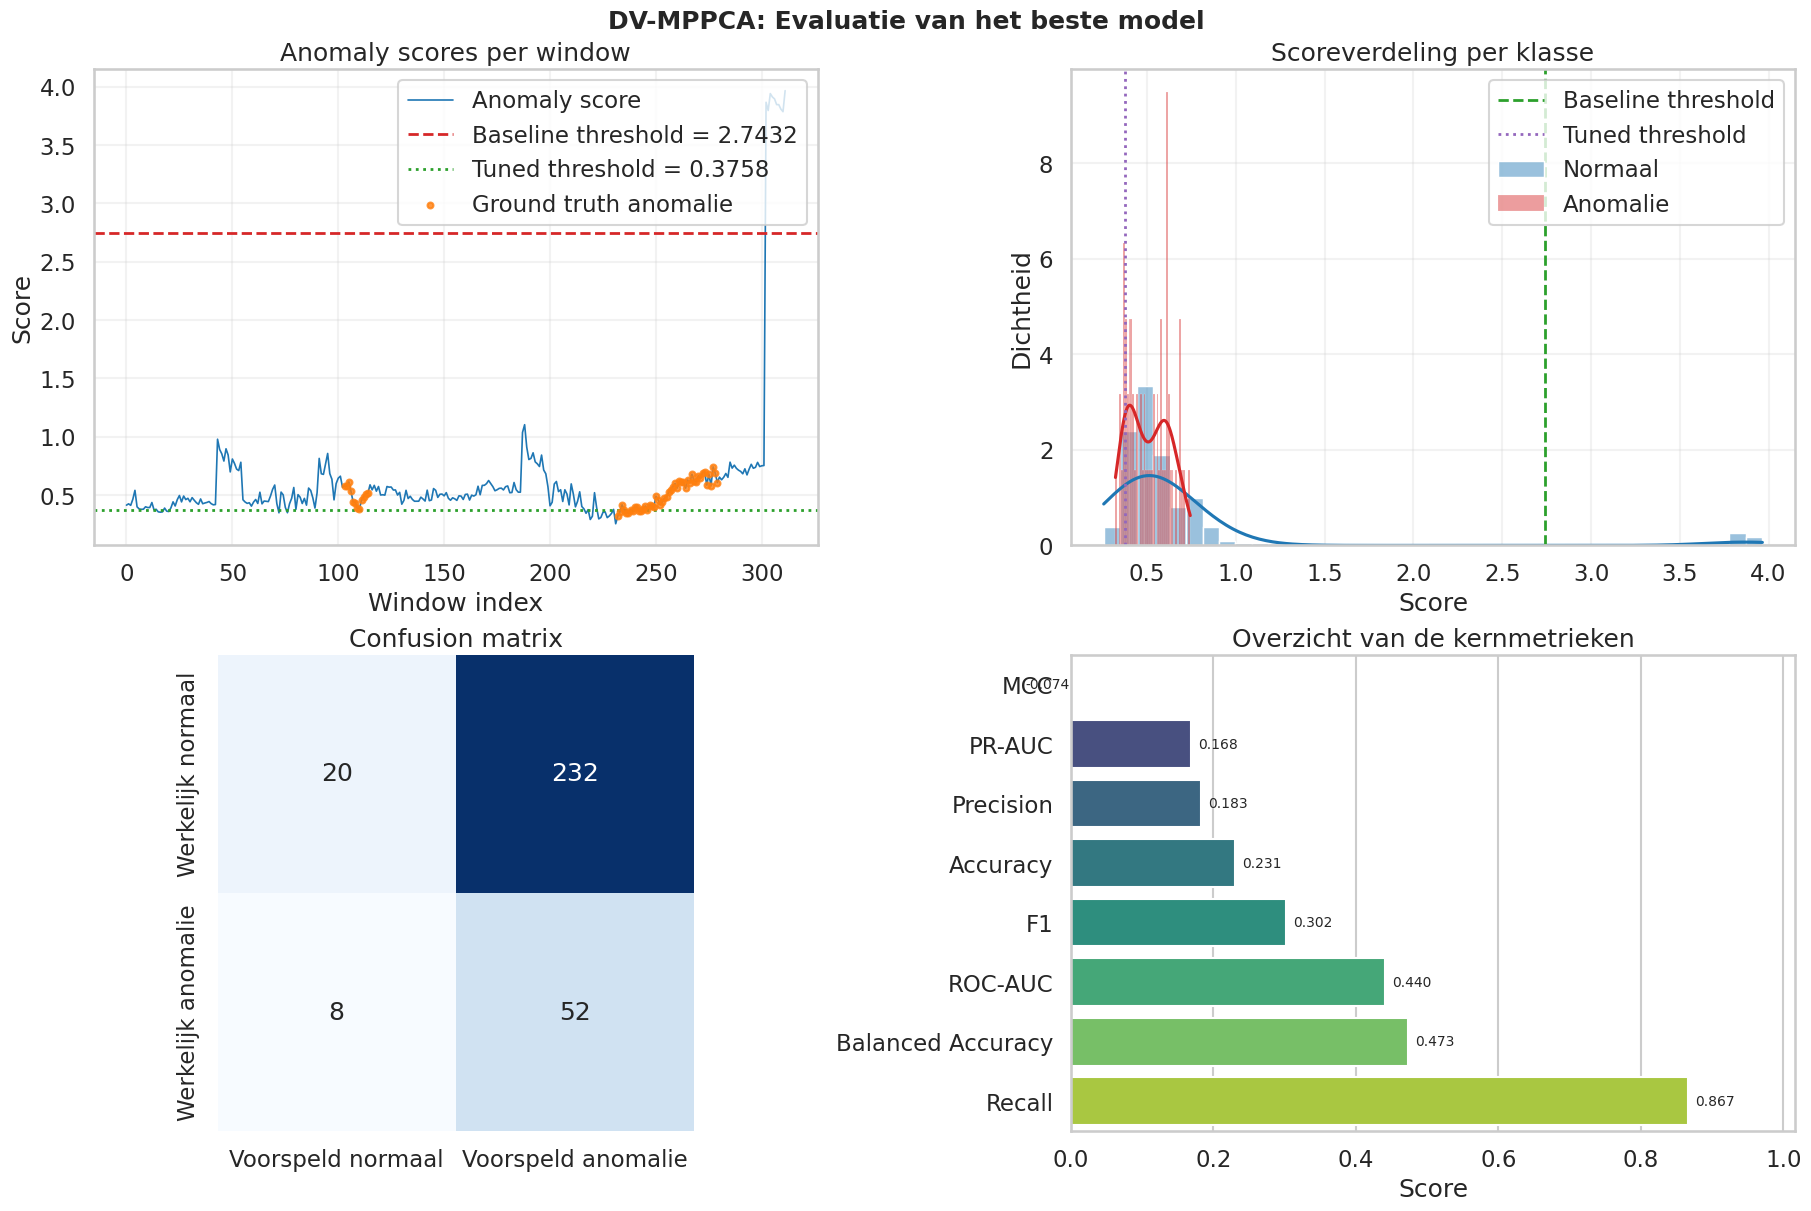

In [70]:
sns.set_theme(style='whitegrid', context='talk')

# Gebruik de reeds beschikbare evaluatievariabelen uit de notebook-kernel
# en maak de scorekaartcel daarmee zelfvoorzienend.
eval_scores_best = scores_synth_eval
y_true_window = y_true_eval
baseline_threshold_best = clean_calibration_threshold
tuned_threshold_best = best_threshold
cm_best = cm

precision_best, recall_best, f1_best, _ = precision_recall_fscore_support(
    y_true_window, y_pred_eval, average='binary', zero_division=0
)
accuracy_best = accuracy_score(y_true_window, y_pred_eval)
balanced_acc_best = balanced_accuracy_score(y_true_window, y_pred_eval)
mcc_best = matthews_corrcoef(y_true_window, y_pred_eval)
roc_auc_best = roc_auc_score(y_true_window, eval_scores_best)
pr_auc_best = average_precision_score(y_true_window, eval_scores_best)

metrics_best_df = pd.DataFrame({
    'Metric': [
        'Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1',
        'MCC', 'ROC-AUC', 'PR-AUC'
    ],
    'Value': [
        accuracy_best, balanced_acc_best, precision_best, recall_best, f1_best,
        mcc_best, roc_auc_best, pr_auc_best
    ]
})

fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)
fig.suptitle('DV-MPPCA: Evaluatie van het beste model', fontsize=18, fontweight='bold')

# Plot 1: anomaly scores per window
ax1 = axes[0, 0]
ax1.plot(eval_scores_best, color='#1f77b4', linewidth=1.2, label='Anomaly score')
ax1.axhline(
    baseline_threshold_best,
    color='#d62728',
    linestyle='--',
    linewidth=2,
    label=f'Baseline threshold = {baseline_threshold_best:.4f}',
)
ax1.axhline(
    tuned_threshold_best,
    color='#2ca02c',
    linestyle=':',
    linewidth=2,
    label=f'Tuned threshold = {tuned_threshold_best:.4f}',
)

anom_idx = np.where(y_true_window == 1)[0]
ax1.scatter(
    anom_idx,
    eval_scores_best[anom_idx],
    s=18,
    color='#ff7f0e',
    alpha=0.8,
    label='Ground truth anomalie',
    zorder=5,
)

ax1.set_title('Anomaly scores per window')
ax1.set_xlabel('Window index')
ax1.set_ylabel('Score')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.25)

# Plot 2: scoreverdeling per klasse
ax2 = axes[0, 1]
sns.histplot(
    eval_scores_best[y_true_window == 0],
    bins=40,
    kde=True,
    stat='density',
    color='#1f77b4',
    alpha=0.45,
    label='Normaal',
    ax=ax2,
)
sns.histplot(
    eval_scores_best[y_true_window == 1],
    bins=40,
    kde=True,
    stat='density',
    color='#d62728',
    alpha=0.45,
    label='Anomalie',
    ax=ax2,
)
ax2.axvline(baseline_threshold_best, color='#2ca02c', linestyle='--', linewidth=2, label='Baseline threshold')
ax2.axvline(tuned_threshold_best, color='#9467bd', linestyle=':', linewidth=2, label='Tuned threshold')
ax2.set_title('Scoreverdeling per klasse')
ax2.set_xlabel('Score')
ax2.set_ylabel('Dichtheid')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.25)

# Plot 3: confusion matrix
ax3 = axes[1, 0]
sns.heatmap(
    cm_best,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    square=True,
    xticklabels=['Voorspeld normaal', 'Voorspeld anomalie'],
    yticklabels=['Werkelijk normaal', 'Werkelijk anomalie'],
    ax=ax3,
)
ax3.set_title('Confusion matrix')
ax3.set_xlabel('')
ax3.set_ylabel('')

# Plot 4: metric overview
ax4 = axes[1, 1]
metric_plot_df = metrics_best_df.sort_values('Value', ascending=True)

sns.barplot(
    data=metric_plot_df,
    x='Value',
    y='Metric',
    hue='Metric',
    dodge=False,
    palette='viridis',
    legend=False,
    ax=ax4,
)

for i, value in enumerate(metric_plot_df['Value']):
    ax4.text(min(value + 0.01, 1.02), i, f'{value:.3f}', va='center', fontsize=10)

ax4.set_xlim(0, max(1.0, metric_plot_df['Value'].max() + 0.15))
ax4.set_title('Overzicht van de kernmetrieken')
ax4.set_xlabel('Score')
ax4.set_ylabel('')

plt.show()